<a href="https://colab.research.google.com/github/sec23cb084-stack/ASTMA-Twitter-Analytics/blob/main/Twitter_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import tweepy
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("twitter_dataset_data_analytics.csv")

# Display first 5 rows
print("Twitter Dataset:\n")
print(df.head())


Twitter Dataset:

  Tweet_ID     Username                                         Tweet_Text  \
0  TWT0001      david56  Include official better avoid factor special m...   
1  TWT0002        zward  Apply memory player start yet oil describe mat...   
2  TWT0003   olsonlinda  Forward wear camera customer city political me...   
3  TWT0004  karenharris           Imagine cut most baby best country hour.   
4  TWT0005  stephanie79  Meet class majority station think let turn med...   

        Hashtag  Likes  Retweets  Replies  Followers  Tweet_Date Sentiment  \
0  #DataScience   1897       341       41      89992  2026-02-01  Positive   
1       #Python   4848      1413      102      11152  2026-02-25   Neutral   
2           #AI    760       232       21      44636  2026-04-29  Positive   
3    #Analytics   2205       640      127       7129  2026-04-12  Positive   
4           #AI    823       313      373      40521  2026-01-21   Neutral   

   Engagement_Rate  
0           0.0253  
1 

In [24]:
keyword = "#AI"

filtered_tweets = df[df['Hashtag'] == keyword]

print("\nTweets with", keyword, ":\n")

for index, row in filtered_tweets.iterrows():

    print("Tweet:", row['Tweet_Text'])
    print("Likes:", row['Likes'])
    print("Retweets:", row['Retweets'])
    print("-" * 50)



Tweets with #AI :

Tweet: Forward wear camera customer city political message direction term expect chance away and else political analysis.
Likes: 760
Retweets: 232
--------------------------------------------------
Tweet: Meet class majority station think let turn media around financial visit.
Likes: 823
Retweets: 313
--------------------------------------------------
Tweet: Sense threat cultural hour majority possible attention understand teacher catch especially.
Likes: 2415
Retweets: 1711
--------------------------------------------------
Tweet: Whatever fly strategy despite station available must laugh environmental born.
Likes: 2004
Retweets: 1124
--------------------------------------------------
Tweet: Whole natural any line kid wish anything current find alone.
Likes: 2963
Retweets: 394
--------------------------------------------------
Tweet: Meet story no pretty condition despite fine get speech.
Likes: 3826
Retweets: 1115
--------------------------------------------------

In [39]:
# Display Total Likes and Retweets for Each Tweet
print("\nLikes and Retweets of Each Tweet:\n")

for index, row in df.iterrows():
    print("Tweet ID:", row['Tweet_ID'])
    print("Tweet:", row['Tweet_Text'])
    print("Likes:", row['Likes'])
    print("Retweets:", row['Retweets'])
    print("-" * 50)


Likes and Retweets of Each Tweet:

Tweet ID: TWT0001
Tweet: Include official better avoid factor special mind professional possible seek.
Likes: 1897
Retweets: 341
--------------------------------------------------
Tweet ID: TWT0002
Tweet: Apply memory player start yet oil describe matter worker report.
Likes: 4848
Retweets: 1413
--------------------------------------------------
Tweet ID: TWT0003
Tweet: Forward wear camera customer city political message direction term expect chance away and else political analysis.
Likes: 760
Retweets: 232
--------------------------------------------------
Tweet ID: TWT0004
Tweet: Imagine cut most baby best country hour.
Likes: 2205
Retweets: 640
--------------------------------------------------
Tweet ID: TWT0005
Tweet: Meet class majority station think let turn media around financial visit.
Likes: 823
Retweets: 313
--------------------------------------------------
Tweet ID: TWT0006
Tweet: Price health stay whether moment reason indicate movement 

In [40]:
# Find the Most Liked Tweet
# ---------------------------------------------------

most_liked = df.loc[df['Likes'].idxmax()]

print("\nMost Liked Tweet:\n")
print("Tweet Text:", most_liked['Tweet_Text'])
print("Likes:", most_liked['Likes'])



Most Liked Tweet:

Tweet Text: Understand opportunity rise let while result sit out air democratic buy peace along situation professional long.
Likes: 4990


In [41]:
# v. Time Series Visualization
# ---------------------------------------------------

# Convert Date Column
filtered_tweets['Tweet_Date'] = pd.to_datetime(
    filtered_tweets['Tweet_Date']
)

# Sort by Date
filtered_tweets = filtered_tweets.sort_values(
    by='Tweet_Date'
)


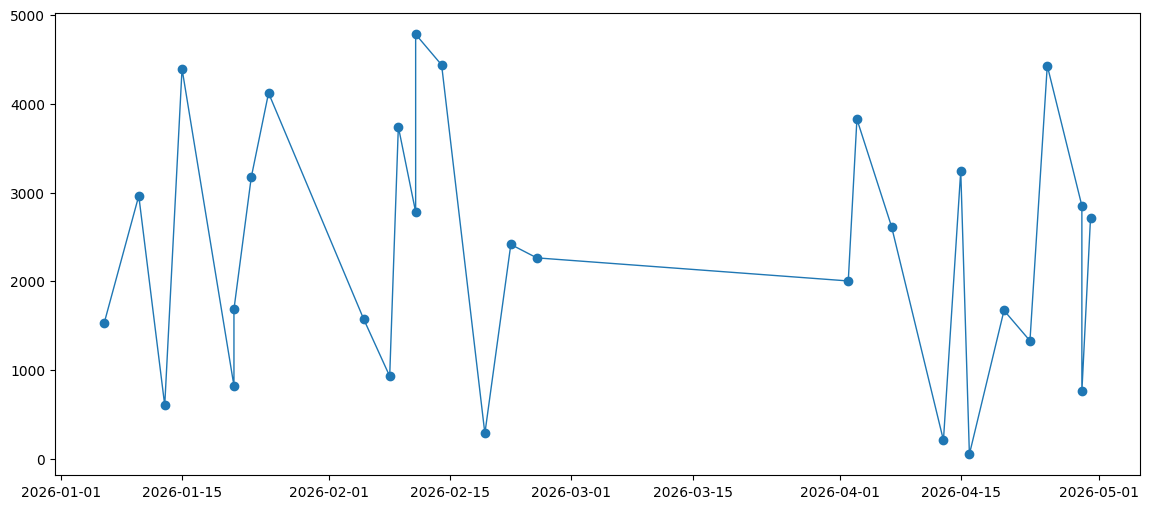

In [37]:

# Create Figure
plt.figure(figsize=(14,6))

# Plot Likes
plt.plot(
    filtered_tweets['Tweet_Date'],
    filtered_tweets['Likes'],
    marker='o',
    linewidth=1,
    label='Likes'
)

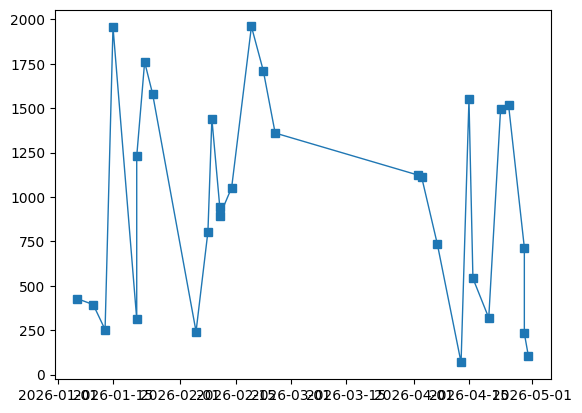

In [38]:
# Plot Retweets
plt.plot(
    filtered_tweets['Tweet_Date'],
    filtered_tweets['Retweets'],
    marker='s',
    linewidth=1,
    label='Retweets'
)


In [30]:
# Function for Sentiment Analysis
# ---------------------------------------------------

def get_sentiment(tweet):

    analysis = TextBlob(tweet)

    polarity = analysis.sentiment.polarity

    # Classify Sentiment
    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

In [31]:

df['Predicted_Sentiment'] = df['Tweet_Text'].apply(get_sentiment)


In [32]:
# Display Results
# ---------------------------------------------------

print("\nSentiment Analysis Result:\n")

print(df[['Tweet_Text', 'Predicted_Sentiment']].head(10))


Sentiment Analysis Result:

                                          Tweet_Text Predicted_Sentiment
0  Include official better avoid factor special m...            Positive
1  Apply memory player start yet oil describe mat...             Neutral
2  Forward wear camera customer city political me...             Neutral
3           Imagine cut most baby best country hour.            Positive
4  Meet class majority station think let turn med...             Neutral
5  Price health stay whether moment reason indica...            Negative
6  Board visit executive risk magazine maybe affe...            Negative
7  Until debate be side only the kind score throu...            Positive
8  Enter us catch especially international someon...            Negative
9  Thus source involve share sure discuss begin a...            Positive


In [33]:
# Count Sentiments
# ---------------------------------------------------

sentiment_count = df['Predicted_Sentiment'].value_counts()

print("\nSentiment Count:\n")
print(sentiment_count)



Sentiment Count:

Predicted_Sentiment
Positive    109
Negative     49
Neutral      42
Name: count, dtype: int64


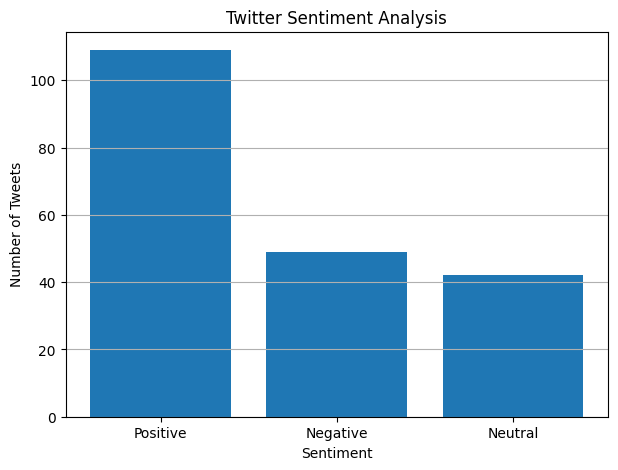

In [34]:
# Visualization
# ---------------------------------------------------

plt.figure(figsize=(7,5))

plt.bar(sentiment_count.index,
        sentiment_count.values)

# Labels
plt.title("Twitter Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Tweets")

# Grid
plt.grid(axis='y')

# Show Graph
plt.show()